# 1. Import Necessary Libraries
Import `torch` for modeling, `terratorch` for the backbone, `h5py` for data, and `matplotlib` with `seaborn` for visualization.

In [1]:
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from terratorch import BACKBONE_REGISTRY
from pathlib import Path
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load Model
Initialize the pre-trained `terramind_v1_tiny` backbone. We specify the 7 bands (RGB, RedEdge, NIR) used for domain alignment.

In [2]:
backbone_name = "terramind_v1_tiny"

# We use the 8-band mapping to match the expected inputs
COMPARED_BANDS = {
    "S2L1C": {
        "B02": 0, "B03": 1, "B04": 2, 
        "B05": 3, "B06": 4, "B07": 5, "B08": 6,
    }
}

encoder = BACKBONE_REGISTRY.build(
    backbone_name,
    pretrained=True,
    modalities=["S2L1C"],
    bands=COMPARED_BANDS,
).to(device).eval()

In [ ]:
from terratorch.tasks import SemanticSegmentationTask

encoder_sim = BACKBONE_REGISTRY.build(
    "terramind_v1_tiny",
    pretrained=True,
    modalities=["S2L1C"],
    bands=COMPARED_BANDS,
).to(device).eval()

#pth_path = "/shared/home/elucas/scratch/terra-sat-drift/outputs/terramind_terramind_v1_tiny_uda_mmd.pth"
pth_path = "/shared/home/elucas/scratch/terra-sat-drift/outputs/terramind_v1_tiny_simulated_v5_256/terramind_v1_tiny_simulated_v5_256/checkpoints/best-val_mIoU.ckpt"

checkpoint = torch.load(pth_path, map_location=device)

# 2. Extraire le dictionnaire de poids réel
lightning_state_dict = checkpoint["state_dict"]

# 3. Nettoyer les préfixes ajoutés par PyTorch Lightning / Terratorch
clean_state_dict = {}
for key, value in lightning_state_dict.items():
    # Les préfixes courants dans Terratorch sont 'model.backbone.', 'model.encoder.' ou 'backbone.'
    clean_key = key
    for prefix in ["model.backbone.", "model.encoder.", "backbone.", "model."]:
        if clean_key.startswith(prefix):
            clean_key = clean_key.replace(prefix, "", 1)
            break # On arrête au premier préfixe trouvé
            
    clean_state_dict[clean_key] = value

# 4. Injecter les poids dans le modèle
# strict=False permet d'ignorer les poids supplémentaires du checkpoint (ex: le décodeur de la tâche de segmentation)
encoder_sim.load_state_dict(clean_state_dict, strict=False)

# 5. Passer en mode évaluation
encoder_sim.eval()

print("Domain-adapted weights successfully loaded!")

Domain-adapted weights successfully loaded!


# 2.1 Load Fine-tuned Model (Simulated Data)
Loading the model fine-tuned on simulated data (Sen1Floods11) to compare domain alignment robustness.

# 3. Prepare Input Pair
Extract a pair of Sentinel-2B (Source) and Phi-Sat-2 (Target) images from the processed dataset.

In [4]:
h5_path = "/shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5"

with h5py.File(h5_path, 'r') as f:
    sample_idx = np.random.randint(0, len(f['s2b/images']))
    # Load all three components of the triplet
    s2b_img = torch.from_numpy(f['s2b/images'][sample_idx]).float().unsqueeze(0).to(device)
    sim_img = torch.from_numpy(f['sim/images'][sample_idx][:7, :, :]).float().unsqueeze(0).to(device)
    real_img = torch.from_numpy(f['real/images'][sample_idx][:7, :, :]).float().unsqueeze(0).to(device)

print(f"S2B shape:  {s2b_img.shape}")
print(f"Sim shape:  {sim_img.shape}")
print(f"Real shape: {real_img.shape}")

# For backward compatibility in following cells if not updated
source_img = s2b_img
target_img = real_img

S2B shape:  torch.Size([1, 7, 256, 256])
Sim shape:  torch.Size([1, 7, 256, 256])
Real shape: torch.Size([1, 7, 256, 256])


In [5]:
S2L1C_means = [0.2137385, 0.2018788, 0.2082986, 0.2295651, 0.2854537, 0.3122849, 0.3040560]
S2L1C_stds = [0.1675806, 0.1557708, 0.1833702, 0.1823738, 0.1733977, 0.1732131, 0.1679732]

def normalize_for_encoder(img_tensor):
    # Standard normalization for Sentinel-2B (0-1 range for visualization)
    img_tensor = img_tensor / 10000.0
    img_tensor = torch.clamp(img_tensor, min=0.0, max=1.0)
    
    return TF.normalize(img_tensor, mean=S2L1C_means, std=S2L1C_stds)

# 4. Extract Embedding Triplet Tensors
Pass the S2B, Simulated, and Real images through the encoder and extract the feature vectors from the final transformer layer outputs.

In [6]:
with torch.no_grad():
    # Base Model Embeddings
    s2b_seq = encoder(normalize_for_encoder(s2b_img))[-1]
    sim_seq = encoder(normalize_for_encoder(sim_img))[-1]
    real_seq = encoder(normalize_for_encoder(real_img))[-1]
    
    s2b_emb = s2b_seq.mean(dim=1).squeeze(0)
    sim_emb = sim_seq.mean(dim=1).squeeze(0)
    real_emb = real_seq.mean(dim=1).squeeze(0)
    
    # Fine-tuned Model Embeddings
    s2b_seq_sim = encoder_sim(normalize_for_encoder(s2b_img))[-1]
    sim_seq_sim = encoder_sim(normalize_for_encoder(sim_img))[-1]
    real_seq_sim = encoder_sim(normalize_for_encoder(real_img))[-1]
    
    s2b_emb_sim = s2b_seq_sim.mean(dim=1).squeeze(0)
    sim_emb_sim = sim_seq_sim.mean(dim=1).squeeze(0)
    real_emb_sim = real_seq_sim.mean(dim=1).squeeze(0)

# Backward compatibility
source_seq, target_seq = s2b_seq, real_seq
source_emb, target_emb = s2b_emb, real_emb
source_seq_sim, target_seq_sim = s2b_seq_sim, real_seq_sim
source_emb_sim, target_emb_sim = s2b_emb_sim, real_emb_sim

print(f"S2B Shared shape: {s2b_seq.shape}")
print(f"Embedding dimensions: {s2b_emb.shape[0]}")

S2B Shared shape: torch.Size([1, 256, 192])
Embedding dimensions: 192


# 5. Calculate Cosine Similarity
Compute the similarity between the two embedding vectors using the formula: $$S_C(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

In [7]:
similarity_base = F.cosine_similarity(source_emb.unsqueeze(0), target_emb.unsqueeze(0)).item()
similarity_sim = F.cosine_similarity(source_emb_sim.unsqueeze(0), target_emb_sim.unsqueeze(0)).item()

print(f"Cosine Similarity (Base Model):      {similarity_base:.4f}")
print(f"Cosine Similarity (Fine-tuned Sim): {similarity_sim:.4f}")

improvement = (similarity_sim - similarity_base)
print(f"Improvement: {improvement:+.4f}")

Cosine Similarity (Base Model):      0.7744
Cosine Similarity (Fine-tuned Sim): 0.8592
Improvement: +0.0849


In [11]:
import numpy as np

num_samples = 1000 # Adjusted for faster comparison
all_sim_real_sims = []
all_s2_real_sims = []

with h5py.File(h5_path, 'r') as f:
    for i in range(min(num_samples, len(f['s2b/images']))):
        # Load triplet components
        s2b_t = torch.from_numpy(f['s2b/images'][i]).float().unsqueeze(0).to(device)
        sim_t = torch.from_numpy(f['sim/images'][i][:7, :, :]).float().unsqueeze(0).to(device)
        real_t = torch.from_numpy(f['real/images'][i][:7, :, :]).float().unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Extract features from Base Encoder for all three domains
            s2b_layers = encoder_sim(normalize_for_encoder(s2b_t))
            sim_layers = encoder_sim(normalize_for_encoder(sim_t))
            real_layers = encoder_sim(normalize_for_encoder(real_t))
            
            sample_sim_real = []
            sample_s2_real = []
            
            for s2_f, si_f, re_f in zip(s2b_layers, sim_layers, real_layers):
                # Calculate Sim vs Real similarity
                sim_real_sim = F.cosine_similarity(si_f.mean(dim=1), re_f.mean(dim=1))
                sample_sim_real.append(sim_real_sim.item())
                
                # Calculate S2B vs Real similarity
                s2_real_sim = F.cosine_similarity(s2_f.mean(dim=1), re_f.mean(dim=1))
                sample_s2_real.append(s2_real_sim.item())
            
            all_sim_real_sims.append(sample_sim_real)
            all_s2_real_sims.append(sample_s2_real)

# Convert to numpy for averaging
all_sim_real_sims = np.array(all_sim_real_sims)
all_s2_real_sims = np.array(all_s2_real_sims)

mean_sr = all_sim_real_sims.mean(axis=0)
std_sr = all_sim_real_sims.std(axis=0)
mean_s2r = all_s2_real_sims.mean(axis=0)
std_s2r = all_s2_real_sims.std(axis=0)

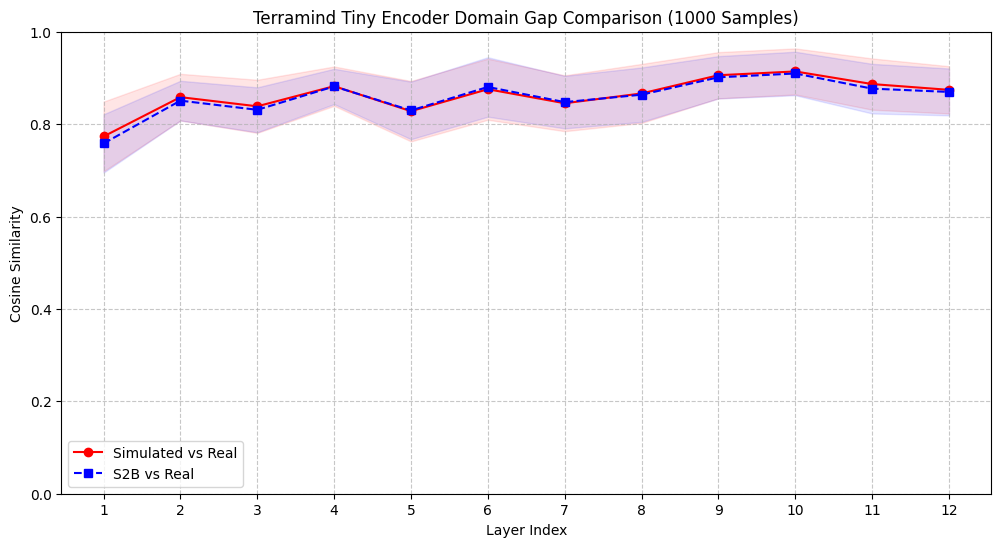

Final Layer Similarity - Sim vs Real: 0.8742
Final Layer Similarity - S2B vs Real: 0.8697
Similarity Gap (Sim Improvement over S2B): +0.0045


In [12]:
# Plotting Comparison
plt.figure(figsize=(12, 6))
layers = range(1, len(mean_sr) + 1)

# Sim vs Real
plt.plot(layers, mean_sr, marker='o', linestyle='-', color='r', label='Simulated vs Real')
plt.fill_between(layers, mean_sr - std_sr, mean_sr + std_sr, alpha=0.1, color='r')

# S2B vs Real
plt.plot(layers, mean_s2r, marker='s', linestyle='--', color='b', label='S2B vs Real')
plt.fill_between(layers, mean_s2r - std_s2r, mean_s2r + std_s2r, alpha=0.1, color='b')

plt.title(f"Terramind Tiny Encoder Domain Gap Comparison ({num_samples} Samples)")
plt.xlabel("Layer Index")
plt.ylabel("Cosine Similarity")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(0.0, 1.0)
plt.legend()
plt.show()

print(f"Final Layer Similarity - Sim vs Real: {mean_sr[-1]:.4f}")
print(f"Final Layer Similarity - S2B vs Real: {mean_s2r[-1]:.4f}")
print(f"Similarity Gap (Sim Improvement over S2B): {mean_sr[-1] - mean_s2r[-1]:+.4f}")

# 9. t-SNE Visualization of Domain Embeddings
Reduce the dimensionality of the aggregated embeddings to 2D using t-SNE to observe the distribution and overlap between Sentinel-2B (Source) and Phi-Sat-2 (Target).

In [13]:
from sklearn.manifold import TSNE
import pandas as pd

tsne_samples = 1000
s2b_base_l, sim_base_l, real_base_l = [], [], []
s2b_ft_l, sim_ft_l, real_ft_l = [], [], []

with h5py.File(h5_path, 'r') as f:
    for i in range(min(tsne_samples, len(f['s2b/images']))):
        s2_t = torch.from_numpy(f['s2b/images'][i]).float().unsqueeze(0).to(device)
        si_t = torch.from_numpy(f['sim/images'][i][:7, :, :]).float().unsqueeze(0).to(device)
        re_t = torch.from_numpy(f['real/images'][i][:7, :, :]).float().unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Base Model
            s2b_base_l.append(encoder(normalize_for_encoder(s2_t))[-1].mean(dim=1).cpu().numpy())
            sim_base_l.append(encoder(normalize_for_encoder(si_t))[-1].mean(dim=1).cpu().numpy())
            real_base_l.append(encoder(normalize_for_encoder(re_t))[-1].mean(dim=1).cpu().numpy())
            
            # FT Model
            s2b_ft_l.append(encoder_sim(normalize_for_encoder(s2_t))[-1].mean(dim=1).cpu().numpy())
            sim_ft_l.append(encoder_sim(normalize_for_encoder(si_t))[-1].mean(dim=1).cpu().numpy())
            real_ft_l.append(encoder_sim(normalize_for_encoder(re_t))[-1].mean(dim=1).cpu().numpy())

def run_tsne_triplet(s2_list, sim_list, real_list):
    X = np.vstack([np.vstack(s2_list), np.vstack(sim_list), np.vstack(real_list)])
    y = (["S2B"] * len(s2_list) + 
         ["Simulated"] * len(sim_list) + 
         ["Real (PhiSat-2)"] * len(real_list))
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X)
    df = pd.DataFrame(X_embedded, columns=['TSNE1', 'TSNE2'])
    df['Domain'] = y
    return df

df_base = run_tsne_triplet(s2b_base_l, sim_base_l, real_base_l)
df_sim = run_tsne_triplet(s2b_ft_l, sim_ft_l, real_ft_l)



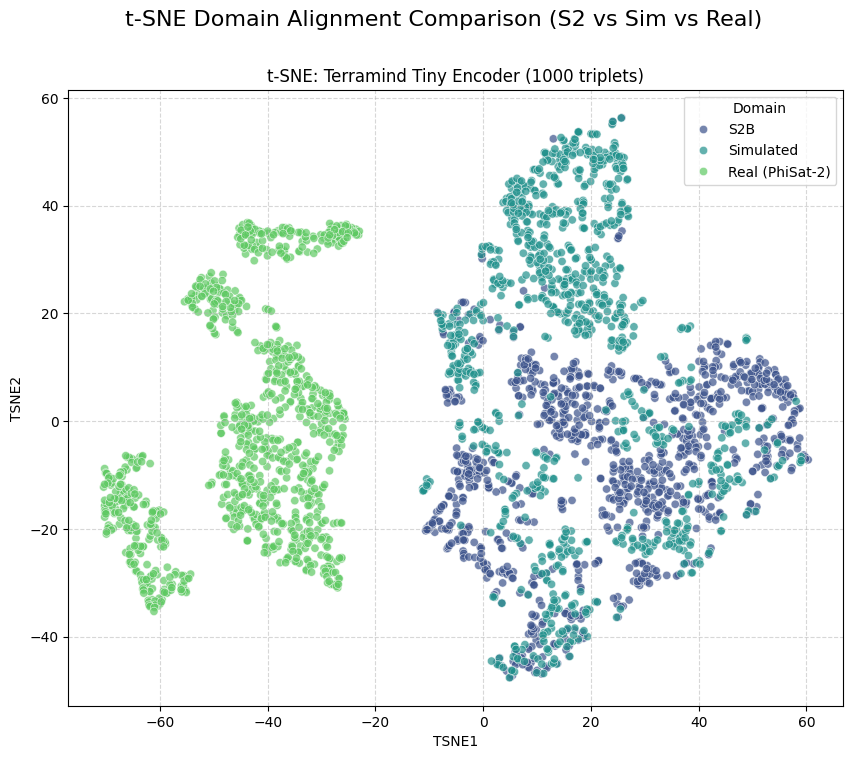

In [14]:

# fig, axes = plt.subplots(1, 2, figsize=(20, 8))
# One subplot
fig, axes = plt.subplots(1, 1, figsize=(10, 8))
sns.scatterplot(data=df_base, x='TSNE1', y='TSNE2', hue='Domain', alpha=0.7, ax=axes, palette='viridis')
axes.set_title(f"t-SNE: Terramind Tiny Encoder ({tsne_samples} triplets)")
axes.grid(True, linestyle='--', alpha=0.5)

#sns.scatterplot(data=df_sim, x='TSNE1', y='TSNE2', hue='Domain', alpha=0.7, ax=axes[1], palette='viridis')
#axes[1].set_title(f"t-SNE: Fine-tuned Model ({tsne_samples} triplets)")
# axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("t-SNE Domain Alignment Comparison (S2 vs Sim vs Real)", fontsize=16)
plt.show()

# 10. MMD Score Calculation & Visualization
Define the MMD loss and calculate the discrepancy between source and target feature distributions for a large sample set.

In [36]:
import torch.nn as nn

class RBFKernel(nn.Module):
    def __init__(self, sigmas=[1.0, 2.0, 4.0, 8.0, 16.0]):
        super(RBFKernel, self).__init__()
        self.sigmas = torch.tensor(sigmas).to(device)

    def forward(self, X, Y):
        X_expanded = X.unsqueeze(1)
        Y_expanded = Y.unsqueeze(0)
        dist_squared = torch.sum((X_expanded - Y_expanded) ** 2, dim=2)
        kernel_val = torch.zeros_like(dist_squared)
        for sigma in self.sigmas:
            gamma = 1.0 / (2.0 * sigma ** 2)
            kernel_val += torch.exp(-gamma * dist_squared)
        return kernel_val / len(self.sigmas)

class MMDLoss(nn.Module):
    def __init__(self, sigmas=[1.0, 2.0, 4.0, 8.0, 16.0]):
        super(MMDLoss, self).__init__()
        self.kernel = RBFKernel(sigmas)

    def forward(self, X, Y):
        k_xx = self.kernel(X, X)
        k_yy = self.kernel(Y, Y)
        k_xy = self.kernel(X, Y)
        n, m = X.size(0), Y.size(0)
        mmd_squared = k_xx.sum() / (n * n) + k_yy.sum() / (m * m) - 2.0 * k_xy.sum() / (n * m)
        return torch.relu(mmd_squared)

In [39]:
# Parameters
mmd_samples = 2000
batch_size = 25
mmd_criterion = MMDLoss().to(device)

# Metrics to track for Base and FT models
# s2r: S2 vs Real
# s2s: S2 vs Sim
# sr_s: Sim vs Real
metrics = {
    'base': {'s2r': [], 's2s': [], 'sr_s': []},
    'ft':   {'s2r': [], 's2s': [], 'sr_s': []}
}

with h5py.File(h5_path, 'r') as f:
    for i in range(0, mmd_samples, batch_size):
        s2_b, sim_b, real_b = [], [], []
        for j in range(i, min(i + batch_size, mmd_samples)):
            s2_b.append(normalize_for_encoder(torch.from_numpy(f['s2b/images'][j]).float()))
            sim_b.append(normalize_for_encoder(torch.from_numpy(f['sim/images'][j][:7, :, :]).float()))
            real_b.append(normalize_for_encoder(torch.from_numpy(f['real/images'][j][:7, :, :]).float()))
        
        s2_t = torch.stack(s2_b).to(device)
        si_t = torch.stack(sim_b).to(device)
        re_t = torch.stack(real_b).to(device)
        
        with torch.no_grad():
            # Base Model Embeddings
            s2_emb_b = encoder(s2_t)[-1].mean(dim=1)
            si_emb_b = encoder(si_t)[-1].mean(dim=1)
            re_emb_b = encoder(re_t)[-1].mean(dim=1)
            
            metrics['base']['s2r'].append(mmd_criterion(s2_emb_b, re_emb_b).item())
            metrics['base']['s2s'].append(mmd_criterion(s2_emb_b, si_emb_b).item())
            metrics['base']['sr_s'].append(mmd_criterion(si_emb_b, re_emb_b).item())
            
            # FT Model Embeddings
            s2_emb_f = encoder_sim(s2_t)[-1].mean(dim=1)
            si_emb_f = encoder_sim(si_t)[-1].mean(dim=1)
            re_emb_f = encoder_sim(re_t)[-1].mean(dim=1)
            
            metrics['ft']['s2r'].append(mmd_criterion(s2_emb_f, re_emb_f).item())
            metrics['ft']['s2s'].append(mmd_criterion(s2_emb_f, si_emb_f).item())
            metrics['ft']['sr_s'].append(mmd_criterion(si_emb_f, re_emb_f).item())


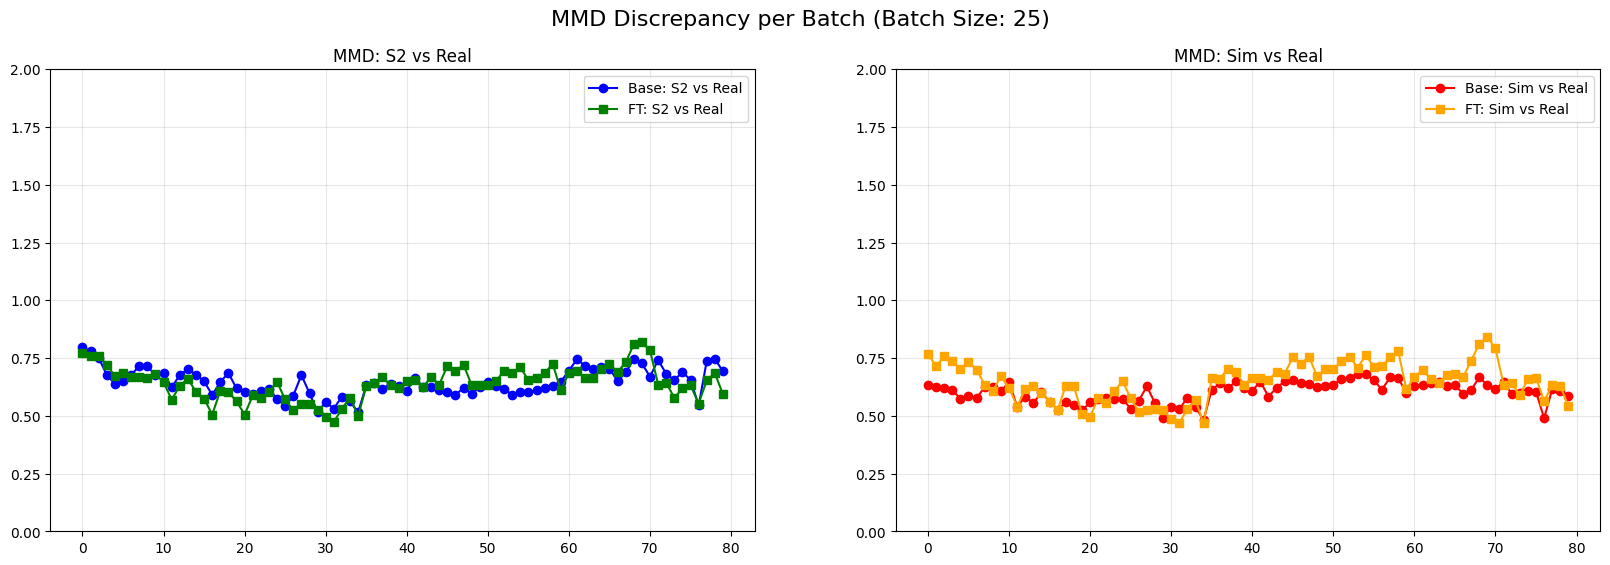

Mean MMD (S2 vs Real) - Base: 0.646444, FT: 0.641381
Mean MMD (Sim vs Real) - Base: 0.603243, FT: 0.649258
Reduction in S2-Real Gap: 0.78%


In [40]:
# Plotting MMD Comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot S2B vs Real
axes[0].plot(metrics['base']['s2r'], marker='o', label='Base: S2 vs Real', color='b')
axes[0].plot(metrics['ft']['s2r'], marker='s', label='FT: S2 vs Real', color='g')
axes[0].set_title("MMD: S2 vs Real")
axes[0].set_ylim(0.0, 2.0)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Sim vs Real (The Domain Gap we are closing)
axes[1].plot(metrics['base']['sr_s'], marker='o', label='Base: Sim vs Real', color='r')
axes[1].plot(metrics['ft']['sr_s'], marker='s', label='FT: Sim vs Real', color='orange')
axes[1].set_title("MMD: Sim vs Real")
axes[1].legend()
axes[1].set_ylim(0.0, 2.0)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"MMD Discrepancy per Batch (Batch Size: {batch_size})", fontsize=16)
plt.show()

print(f"Mean MMD (S2 vs Real) - Base: {np.mean(metrics['base']['s2r']):.6f}, FT: {np.mean(metrics['ft']['s2r']):.6f}")
print(f"Mean MMD (Sim vs Real) - Base: {np.mean(metrics['base']['sr_s']):.6f}, FT: {np.mean(metrics['ft']['sr_s']):.6f}")
print(f"Reduction in S2-Real Gap: {((np.mean(metrics['base']['s2r']) - np.mean(metrics['ft']['s2r'])) / np.mean(metrics['base']['s2r'])) * 100:.2f}%")

## Proxy A-Distance

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

# X is your concatenated embeddings (Sim + Real)
# y is the binary labels (0 for Sim, 1 for Real)
clf = SVC(kernel='linear')
scores = cross_val_score(clf, X, y, cv=5)
error = 1.0 - np.mean(scores)

# Proxy A-Distance: 0 means indistinguishable, 2 means perfectly separable
pad = 2 * (1 - 2 * error)

## UMAP Latent Space Visualization

In [ ]:
from torch.utils.data import Dataset, DataLoader

class PhiSatTripletDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(h5_path, 'r') as f:
            self.length = len(f['s2b/images'])

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        with h5py.File(self.h5_path, 'r') as f:
            s2b = f['s2b/images'][idx]
            # Load 7 bands: B02, B03, B04, B05, B06, B07, B08
            real = f['real/images'][idx][:7, :, :]
            sim = f['sim/images'][idx][:7, :, :]
            
        return {
            's2b': torch.from_numpy(s2b).float(),
            'real': torch.from_numpy(real).float(),
            'sim': torch.from_numpy(sim).float()
        } 

/shared/home/elucas/scratch/terra-sat-drift/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


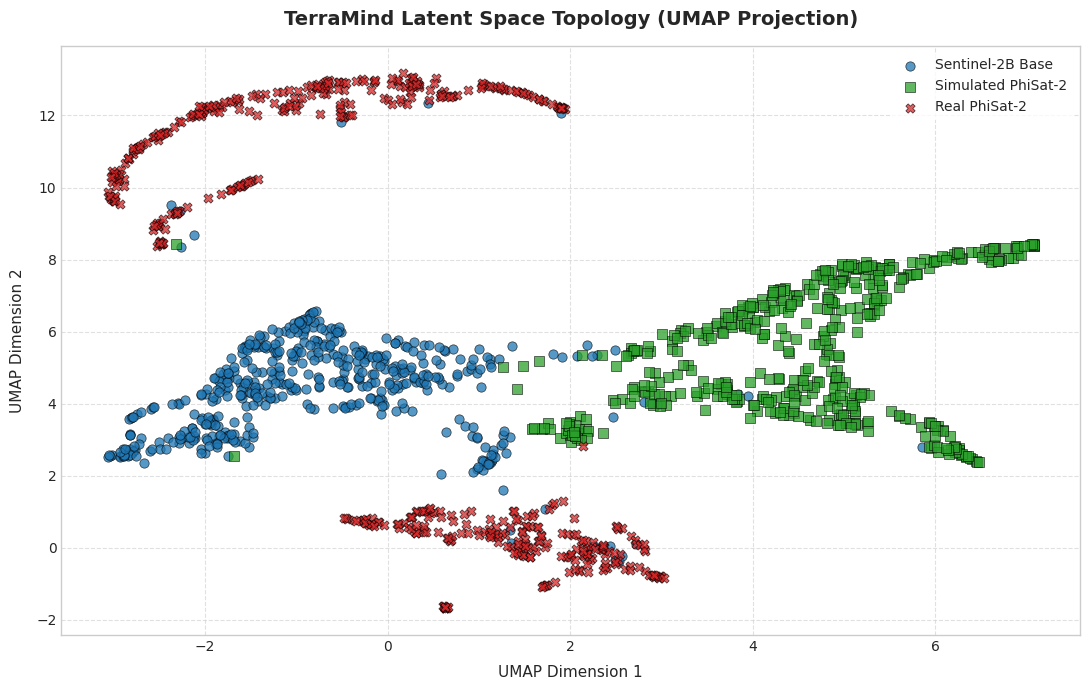

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np
import torch

# Put model in evaluation mode
encoder_sim.eval()

h5_path = "/shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5"
full_dataset = PhiSatTripletDataset(h5_path)

subset_size = 500
torch.manual_seed(42) # For reproducibility
indices = torch.randperm(len(full_dataset))[:subset_size]
dataset = torch.utils.data.Subset(full_dataset, indices)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=4)



embed_s2b_list = []
embed_sim_list = []
embed_real_list = []

# 1. Extraction Loop 
# Iterate through your validation/test dataloader to collect a population of patches
with torch.no_grad():
    for batch in dataloader:
        # Assuming batch returns tensors of shape (B, C, H, W)
        s2b_img = batch["s2b"].to(device)
        sim_img = batch["sim"].to(device)
        real_img = batch["real"].to(device)
        
        # Normalize inputs correctly using your fixed function
        norm_s2b = normalize_for_encoder(s2b_img)
        norm_sim = normalize_for_encoder(sim_img)
        norm_real = normalize_for_encoder(real_img)
        
        # Forward pass to extract tokens
        out_s2b = encoder_sim(norm_s2b)
        out_sim = encoder_sim(norm_sim)
        out_real = encoder_sim(norm_real)
        
        # Extract global representation (CLS token or GAP pooling depending on ViT configuration)
        # Here we assume the CLS token is at index 0: out[:, 0, :]
        embed_s2b_list.append(out_s2b[-1].mean(dim=1))
        embed_sim_list.append(out_sim[-1].mean(dim=1))
        embed_real_list.append(out_real[-1].mean(dim=1))

# 2. Concatenate and Convert to NumPy
s2b_features = torch.cat(embed_s2b_list, dim=0).cpu().numpy()
sim_features = torch.cat(embed_sim_list, dim=0).cpu().numpy()
real_features = torch.cat(embed_real_list, dim=0).cpu().numpy()

# Combine into a single feature matrix for UMAP fitting
X = np.concatenate([s2b_features, sim_features, real_features], axis=0)

# Create tracking arrays for color labeling
labels = (
    ["Sentinel-2B Base"] * len(s2b_features) +
    ["Simulated PhiSat-2"] * len(sim_features) +
    ["Real PhiSat-2"] * len(real_features)
)

# 3. Compute UMAP Embedding
# n_neighbors controls local vs global structure balance
# min_dist controls how tightly UMAP packs points together
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(X)

# 4. Generate the Visualization Plot
plt.style.use('seaborn-v0_8-whitegrid') # Clean academic style grid
plt.figure(figsize=(11, 7))

# Set mapping configurations for consistent color assignment
colors = {
    "Sentinel-2B Base": "#1f77b4",       # Clean Blue
    "Simulated PhiSat-2": "#2ca02c",  # Vibrant Green
    "Real PhiSat-2": "#d62728"        # Sharp Red
}
markers = {
    "Sentinel-2B Base": "o", 
    "Simulated PhiSat-2": "s", 
    "Real PhiSat-2": "X"
}

# Plot domains individually to ensure clean legend grouping
for domain in ["Sentinel-2B Base", "Simulated PhiSat-2", "Real PhiSat-2"]:
    indices = [i for i, label in enumerate(labels) if label == domain]
    plt.scatter(
        embedding_2d[indices, 0],
        embedding_2d[indices, 1],
        c=colors[domain],
        marker=markers[domain],
        label=domain,
        alpha=0.75,
        edgecolors='k',
        linewidths=0.5,
        s=45
    )

plt.title("TerraMind Latent Space Topology (UMAP Projection)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("UMAP Dimension 1", fontsize=11, labelpad=8)
plt.ylabel("UMAP Dimension 2", fontsize=11, labelpad=8)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="best", frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.tight_layout()

plt.show()